In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/Concrete_Data.csv')

## Пояснение к данным
    1. **Cement** — количество цемента. Чем его больше, тем бетон обычно прочнее.
    2. **Blast_furnace_slag** — доменный шлак (добавка для экономии и прочности).
    3. **Fly_ash** — летучая зола (еще одна примесь).
    4. **Water** — количество воды. Важнейший момент: если переборщить с водой, бетон станет жидким и хрупким, а если недолить — он не схватится. Связь нелинейная!
    5. **Superplasticizer** — суперпластификатор (добавка, которая делает смесь пластичной без добавления лишней воды).
    6. **Coarse_aggregate** — крупный заполнитель (гравий, щебень). Создает жесткий «скелет» внутри бетона.
    7. **Fine_aggregate** — мелкий заполнитель (песок). Заполняет пустоты между щебнем.
    8. **Age** — возраст бетона в днях. Бетон прочнее всего становится со временем. Стандартное время затвердевания — 28 дней, после этого он набирает основную силу.
    9. **Concrete_compressive_strength** - показатель качества бетона, какую максимальную нагрузку выдержит в МПа (мегапаскали)

## ВСЯ РАБОТА

In [3]:
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


<Axes: >

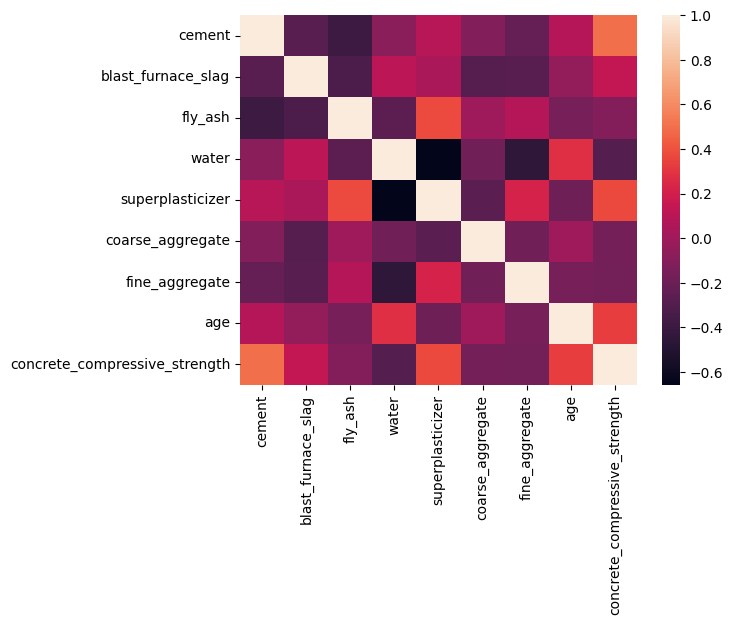

In [5]:
sns.heatmap(df.corr())

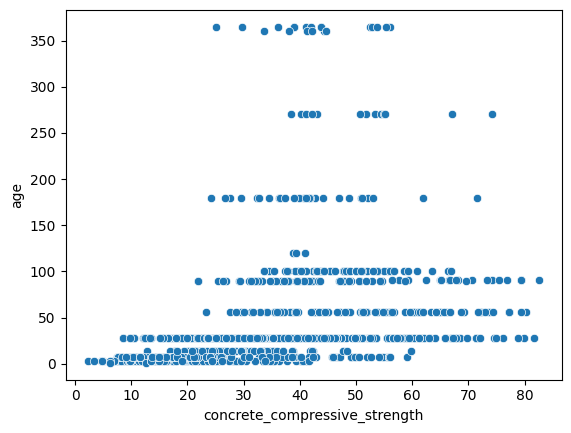

In [6]:
sns.scatterplot(x='concrete_compressive_strength', y='age', data=df);

In [7]:
df[(df['age'] > 250) & (df['concrete_compressive_strength'] > 60)]

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
756,540.0,0.0,0.0,173.0,0.0,1125.0,613.0,270,74.166933
820,525.0,0.0,0.0,189.0,0.0,1125.0,613.0,270,67.113594


In [8]:
right_outliers = (df['age'] > 150) & (df['concrete_compressive_strength'] > 60)

left_outliers = (df['age'] == 365) & (df['concrete_compressive_strength'] < 30)

df = df[~(right_outliers | left_outliers)]

print(f"Строк после тотальной чистки: {len(df)}")

Строк после тотальной чистки: 1024


<Axes: xlabel='concrete_compressive_strength', ylabel='superplasticizer'>

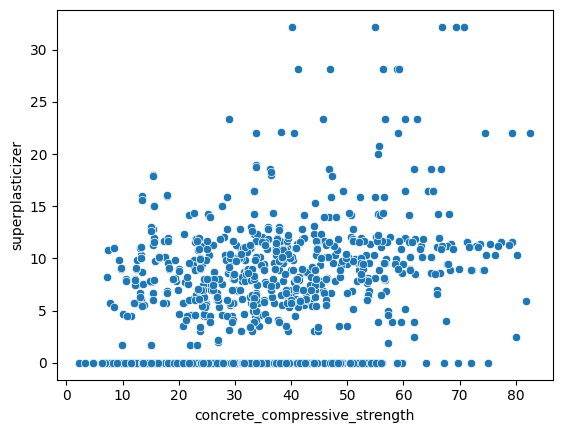

In [9]:
sns.scatterplot(x='concrete_compressive_strength', y='superplasticizer', data=df)

<Axes: xlabel='concrete_compressive_strength', ylabel='water'>

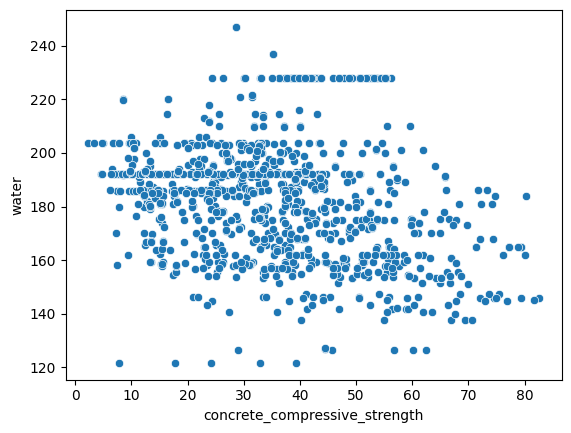

In [10]:
sns.scatterplot(x='concrete_compressive_strength', y='water', data=df)

In [11]:
df[df['water'] > 240]

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
873,237.0,92.0,71.0,247.0,6.0,853.0,695.0,28,28.627044
936,236.9,91.7,71.5,246.9,6.0,852.9,695.4,28,28.629801


In [12]:
df = df.drop(873)
df = df.drop(936)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1022 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1022 non-null   float64
 1   blast_furnace_slag             1022 non-null   float64
 2   fly_ash                        1022 non-null   float64
 3   water                          1022 non-null   float64
 4   superplasticizer               1022 non-null   float64
 5   coarse_aggregate               1022 non-null   float64
 6   fine_aggregate                 1022 non-null   float64
 7   age                            1022 non-null   int64  
 8   concrete_compressive_strength  1022 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 79.8 KB


<Axes: xlabel='concrete_compressive_strength', ylabel='cement'>

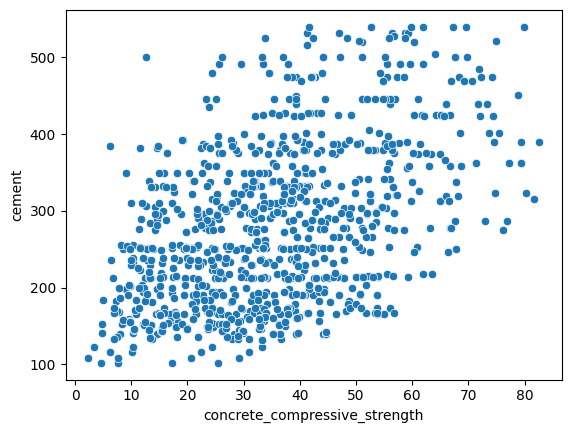

In [14]:
sns.scatterplot(x='concrete_compressive_strength', y='cement', data=df)

In [15]:
df[(df['cement']>480) & (df['concrete_compressive_strength'] < 20)]

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
746,500.0,0.0,0.0,200.0,0.0,1125.0,613.0,1,12.638095


In [16]:
df = df.drop(746)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1021 non-null   float64
 1   blast_furnace_slag             1021 non-null   float64
 2   fly_ash                        1021 non-null   float64
 3   water                          1021 non-null   float64
 4   superplasticizer               1021 non-null   float64
 5   coarse_aggregate               1021 non-null   float64
 6   fine_aggregate                 1021 non-null   float64
 7   age                            1021 non-null   int64  
 8   concrete_compressive_strength  1021 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 79.8 KB


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [19]:
X = df.drop('concrete_compressive_strength', axis=1)

In [20]:
y = df['concrete_compressive_strength']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [22]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()

In [23]:
num_features

['cement',
 'blast_furnace_slag',
 'fly_ash',
 'water',
 'superplasticizer',
 'coarse_aggregate',
 'fine_aggregate',
 'age']

In [24]:
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler_2', StandardScaler()),
    ('model', ElasticNetCV(
        cv=10, 
        l1_ratio=[.1, .5, .7, .9, .95, .99, 1.0], 
        n_jobs=-1, 
        random_state=42
    ))
])

In [25]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [26]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение alpha: 0.008065145030412037
Лучшее значение l1_ratio: 1.0


In [27]:
y_pred = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)

In [28]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)

In [29]:
MAE

5.694711116887173

In [30]:
MSE

51.68854249957944

In [31]:
RMSE

np.float64(7.189474424433224)

In [32]:
r2_train

0.8024273971698388

In [33]:
r2_test

0.8365554995351154

In [34]:
df['concrete_compressive_strength'].mean()

np.float64(35.74219620684918)

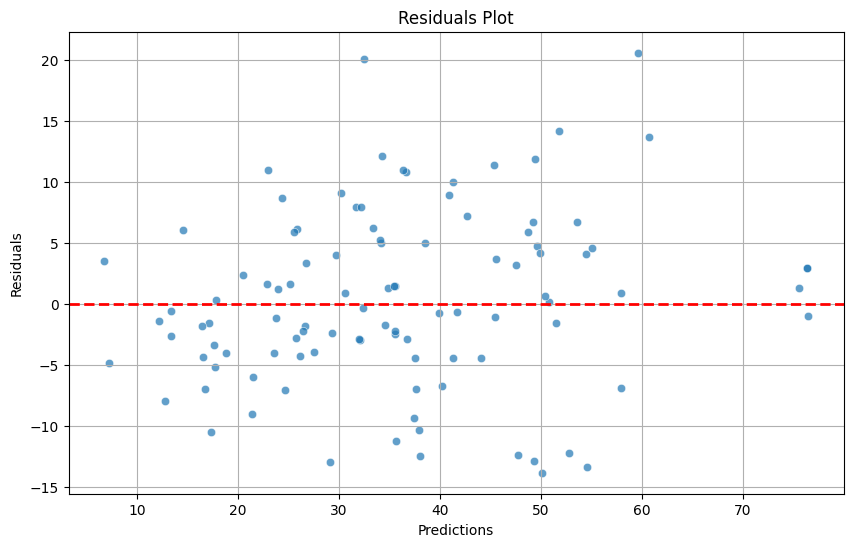

In [35]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title('Residuals Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.grid(True)

In [36]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [37]:
y_full_pred = pipe.predict(X)

In [38]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 0.26809088379835694
Лучшее значение l1_ratio: 1.0


In [39]:
r2_full = r2_score(y, y_full_pred)

In [40]:
r2_full

0.7797026963744891

In [41]:
my_concrete_data = {
    'cement': [320.0],
    'blast_furnace_slag': [100.0],
    'fly_ash': [0.0],
    'water': [180.0],
    'superplasticizer': [8.0],
    'coarse_aggregate': [950.0],
    'fine_aggregate': [750.0],
    'age': [28]
}

In [42]:
my_concrete_df = pd.DataFrame(my_concrete_data)

In [43]:
predicted_strength = pipe.predict(my_concrete_df)

In [44]:
predicted_strength

array([41.71404472])

In [52]:
import json
import os

advanced_report = {
    "project": "Concrete Compressive Strength Prediction",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "R2_full": r2_full,
        "Mean_Concrete_Compressive_Strength": df['concrete_compressive_strength'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [47]:
from joblib import dump, load

In [48]:
dump(pipe, 'model/concrete_compressive_strength_predict_elastic_net_cv_2026_v1.pkl')

['model/concrete_compressive_strength_predict_elastic_net_cv_2026_v1.pkl']

In [49]:
loaded_pipe = load('model/concrete_compressive_strength_predict_elastic_net_cv_2026_v1.pkl')

In [50]:
loaded_pipe.predict(my_concrete_df)

array([41.71404472])